2 - Analise exploratoria

Estatísticas
count    200.000000
mean     170.982797
std       16.117249
min      130.364739
25%      163.911076
50%      169.966465
75%      175.416255
max      234.166370
dtype: float64
Assimetria: 1.54

3 - Visualização do histograma corrompido



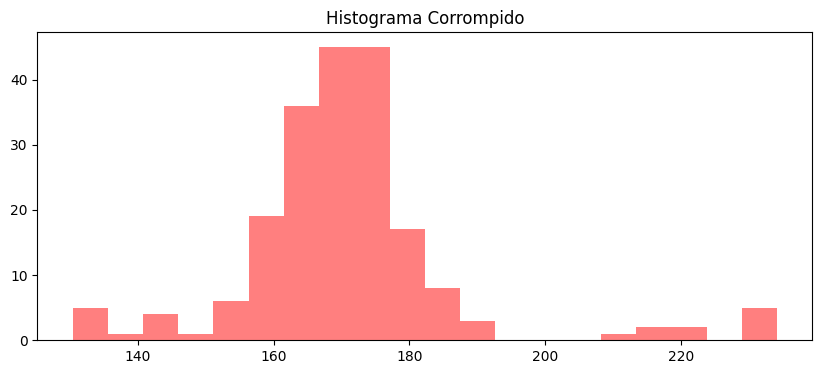

Regressão Linear COM Outliers


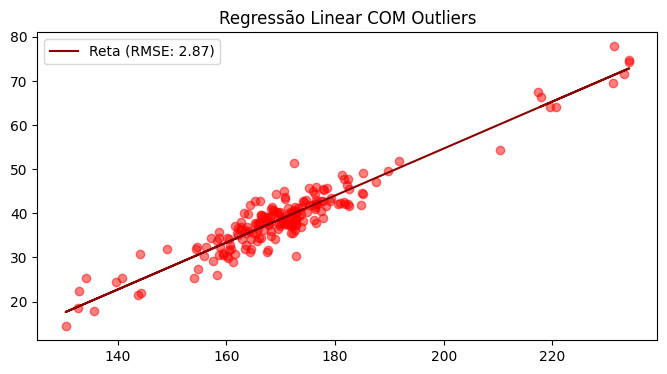

4 - Detecção de Outliers com Boxplot e AIQ


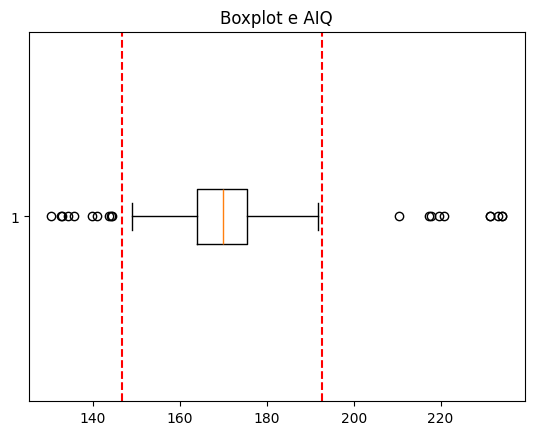

Intervalo de confiança: [146.65 a 192.67]

5 - Eliminação de Outliers

outliers removidos: 20

6 - Histograma Final (Dados Limpos)


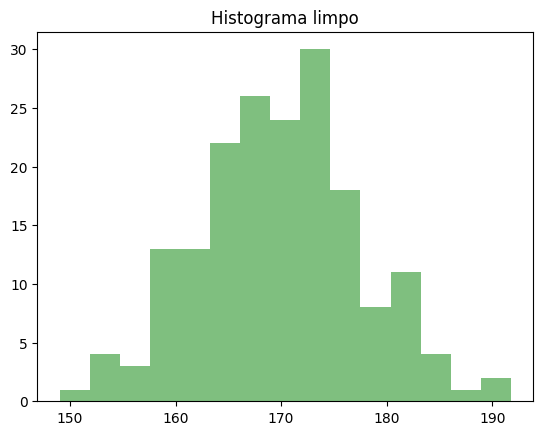

Regressão Linear SEM Outliers


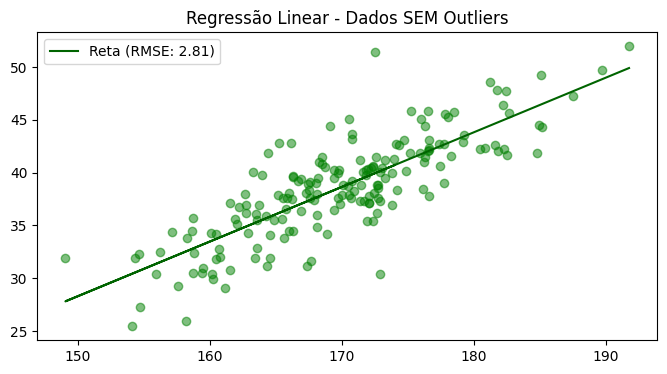

Comparativo lado a lado das regressões
Grafico com os outliers
Grafico sem os outliers


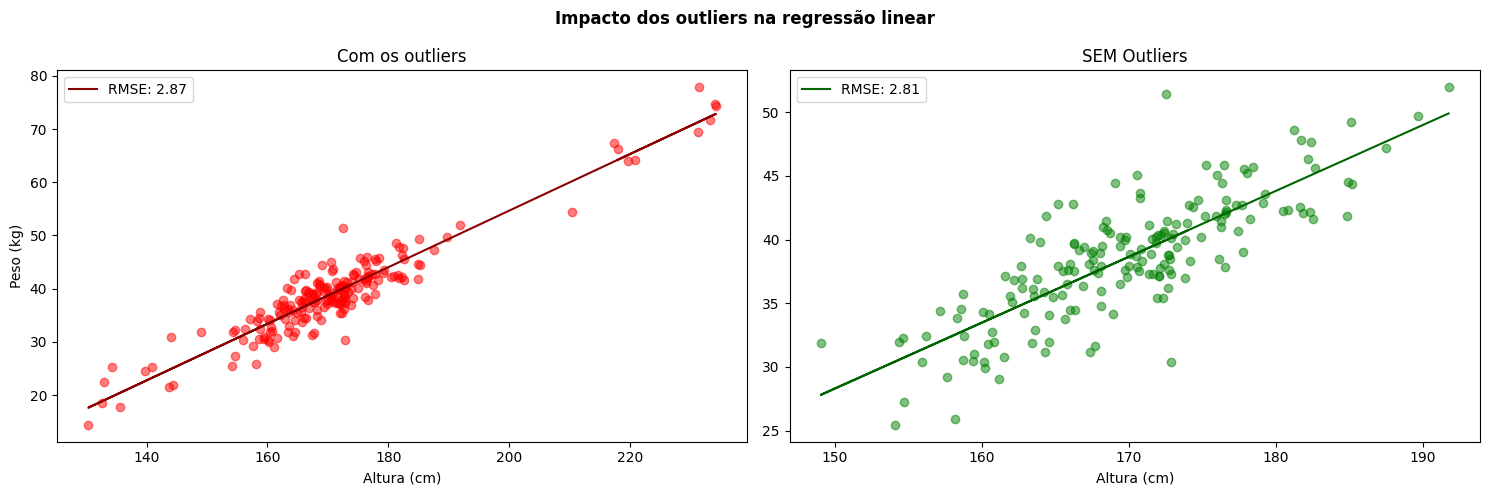

 7 - Conclusão

Feito a analise, notamos que a presença de outliers na base de dados podem distorcer
significamente as estatisticas descritivas e a inclinação da reta de regressão linear.
Assim sendo o tratamento de outliers com bloxplot e AIQ é indispensavel, garantido que os casos raros
não comprometam a interpretaçao dos dados estudados


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


np.random.seed(42)
alturas = np.random.normal(170, 8, 180) 
outliers_pequenos = np.random.uniform(130,145,10)
outliers_grandes = np.random.uniform(210,235, 10)
dados = pd.Series(np.concatenate([alturas, outliers_pequenos, outliers_grandes]))

df = pd.DataFrame({'Altura': dados})
df['Peso'] = 0.55 *df['Altura'] - 55 + np.random.normal(0, 3, size=len(df))

print("2 - Analise exploratoria\n")
print("Estatísticas")
print(dados.describe()) 
print(f"Assimetria: {dados.skew():.2f}")

#print("Regressão antes do tratamento (atividade nova)")#
x_bruto = df[['Altura']]
y_bruto = df[['Peso']]
modelo_bruto = LinearRegression().fit(x_bruto, y_bruto)
pred_bruto = modelo_bruto.predict(x_bruto)
rmse_bruto = np.sqrt(mean_squared_error(y_bruto, pred_bruto))

print("\n3 - Visualização do histograma corrompido\n")
plt.figure(figsize=(10, 4))
plt.hist(dados, bins=20, color='red', alpha=0.5)
plt.title("Histograma Corrompido")
plt.show()

print("Regressão Linear COM Outliers")
plt.figure(figsize=(8, 4))
plt.scatter(df['Altura'], df['Peso'], color='red', alpha=0.5)
plt.plot(df['Altura'], pred_bruto, color='darkred', label=f'Reta (RMSE: {rmse_bruto:.2f})')
plt.title("Regressão Linear COM Outliers")
plt.legend()
plt.show()

print("4 - Detecção de Outliers com Boxplot e AIQ")
q1 = dados.quantile(0.25)
q3 = dados.quantile(0.75)
aiq = q3 - q1
limite_inf = q1 - 1.5 * aiq
limite_sup = q3 + 1.5 * aiq

plt.boxplot(dados, vert=False)
plt.axvline(limite_inf, color='r', linestyle='--')
plt.axvline(limite_sup, color='r', linestyle='--')
plt.title("Boxplot e AIQ")
plt.show()
print(f"Intervalo de confiança: [{limite_inf:.2f} a {limite_sup:.2f}]\n")

print("5 - Eliminação de Outliers\n")
dados_limpos = dados[(dados >= limite_inf) & (dados <= limite_sup)]
print(f"outliers removidos: {len(dados) - len(dados_limpos)}\n")

#print("Regressão apos o tratameto (atividade nova)")#
df_limpo = df[(df['Altura'] >= limite_inf) & (df['Altura'] <= limite_sup)].copy()
x_limpo = df_limpo[['Altura']]
y_limpo = df_limpo[['Peso']]
modelo_limpo = LinearRegression().fit(x_limpo, y_limpo)
pred_limpo = modelo_limpo.predict(x_limpo)
rmse_limpo = np.sqrt(mean_squared_error(y_limpo, pred_limpo))

print("6 - Histograma Final (Dados Limpos)")
plt.hist(dados_limpos, bins=15, color='green', alpha=0.5)
plt.title("Histograma limpo")
plt.show()

print("Regressão Linear SEM Outliers")
plt.figure(figsize=(8, 4))
plt.scatter(df_limpo['Altura'], df_limpo['Peso'], color='green', alpha=0.5)
plt.plot(df_limpo['Altura'], pred_limpo, color='darkgreen', label=f'Reta (RMSE: {rmse_limpo:.2f})')
plt.title("Regressão Linear - Dados SEM Outliers")
plt.legend()
plt.show()

print("Comparativo lado a lado das regressões")
fig, axes = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle('Impacto dos outliers na regressão linear', fontsize=12, fontweight='bold')

print("Grafico com os outliers")
axes[0].scatter(df['Altura'], df['Peso'], color='red', alpha=0.5)
axes[0].plot(df['Altura'], pred_bruto, color='darkred', label=f'RMSE: {rmse_bruto:.2f}')
axes[0].set_title("Com os outliers")
axes[0].set_xlabel("Altura (cm)")
axes[0].set_ylabel("Peso (kg)")
axes[0].legend()

print("Grafico sem os outliers")
axes[1].scatter(df_limpo['Altura'], df_limpo['Peso'], color='green', alpha=0.5)
axes[1].plot(df_limpo['Altura'], pred_limpo, color='darkgreen', label=f'RMSE: {rmse_limpo:.2f}')
axes[1].set_title("SEM Outliers")
axes[1].set_xlabel("Altura (cm)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(" 7 - Conclusão\n")
print("Feito a analise, notamos que a presença de outliers na base de dados podem distorcer\n"
       "significamente as estatisticas descritivas e a inclinação da reta de regressão linear.\n"
       "Assim sendo o tratamento de outliers com bloxplot e AIQ é indispensavel, garantido que os casos raros\n" \
       "não comprometam a interpretaçao dos dados estudados")